Task 1

In [6]:
# Loading the data 
from pathlib import Path

import kagglehub
import pandas as pd

COMPETITION_NAME = "50-007-machine-learning-may-2026"

competition_path = Path(kagglehub.competition_download(COMPETITION_NAME))

train_features_df = pd.read_csv(competition_path / "train_features.csv")

test_features_df = pd.read_csv(competition_path / "test_features.csv")

submission_df = pd.read_csv(competition_path / "sample_submission.csv")

In [16]:
# import packages
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Test dataset features
X_test_submission = test_features_df.iloc[:, 1:]

# Original train dataset
X = train_features_df.iloc[:, 2:]
y = train_features_df.iloc[:, 1]

# Using the train test split function (75% for training, 25% for validating)
X_train, X_validate, y_train, y_validate = train_test_split(X, y, random_state=10, test_size=0.25, shuffle=True, stratify=y)

def fit_normalizer(X):
    mean = np.asarray(X.mean(axis=0), dtype=float)
    std = np.asarray(X.std(axis=0), dtype=float)
    
    # Prevent division by zero for constant features
    std = np.where(std == 0, 1.0, std)

    return mean, std

def transform(X, mean, std):
    return (np.asarray(X, dtype=float) - mean) / std

In [11]:
def sigmoid(z):
    return 1.0/(1 + np.exp(-z))

def loss(y, y_hat):
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon) # Ensures that NaN is not returned for log(0)
    loss = -np.mean(y * (np.log(y_hat)) + (1 - y) * np.log(1-y_hat))
    return loss

def gradients(X, y, y_hat): 
    m = X.shape[0] # number of training examples

    # Gradient of loss w.r.t weights.
    dw = (1 / m) * np.dot(X.T, (y_hat - y))

    # Gradient of loss w.r.t bias.
    db = (1 / m) * np.sum((y_hat - y)) 

    return dw, db

def train(X, y, epochs, lr):
    # m-> number of training examples
    # n-> number of features 
    m, n = X.shape

    # Initializing weights and bias to zeros.
    w = np.zeros((n,1))
    b = 0

    # Reshaping y.
    y = np.asarray(y, dtype=float).reshape(-1, 1)

    # Empty list to store losses.
    losses = []

    previous_loss = float("inf")

    # Training loop.
    for epoch in range(epochs):

        # Calculating hypothesis/prediction.
        y_hat = sigmoid(np.dot(X, w) + b)

        # Getting the gradients of loss w.r.t parameters.
        dw, db = gradients(X, y, y_hat)

        # Updating the parameters.
        w -= lr * dw
        b -= lr * db

        # Calculating loss and appending it in the list.
        current_loss = loss(y, sigmoid(X @ w + b))
        losses.append(current_loss)

        if abs(previous_loss - current_loss) < 1e-6: # Stop after convergence
            print(f"Converged at epoch {epoch}")
            break

        previous_loss = current_loss

    # returning weights, bias and losses(List).
    return w, b, losses

def predict_proba(X, w, b):
    X = np.asarray(X, dtype=float)
    return sigmoid(X @ w + b).reshape(-1)

def predict(X, w, b): 
    # if y_hat >= 0.5 --> round up to 1
    # if y_hat < 0.5 --> round down to 0
    probabilities = predict_proba(X, w, b)
    return (probabilities >= 0.5).astype(int) # Threshold = 0.5 


In [ ]:
# Code to train then compare performance of custom LogReg model and sklearn model
from sklearn.linear_model import LogisticRegression

mean, std = fit_normalizer(X_train)
X_train_scaled = transform(X_train, mean, std)
X_validate_scaled = transform(X_validate, mean, std)

# Train custom model and sklearn model using 75% of train_features.csv dataset
sklearn_model = LogisticRegression(C=np.inf, max_iter=5000).fit(X_train_scaled, y_train) # C=np.inf for penalty = None
w, b, train_losses = train(X_train_scaled, y_train, 500, 0.1)

# Predict values (remaining 25% of  train_features.csv dataset used for validation) for comparison between custom model and scikit-learn model
custom_pred = predict(X_validate_scaled, w, b)
sklearn_pred = sklearn_model.predict(X_validate_scaled)

In [ ]:
# Code to train and predict values of test dataset
full_mean, full_std = fit_normalizer(X)
X_scaled = transform(X, full_mean, full_std)
X_test_scaled = transform(X_test_submission, full_mean, full_std)

# Retrain custom model using full train dataset (100%)
w, b, test_losses = train(X_scaled, y, 500, 0.1) 

# Predicting values from test dataset
custom_pred_test = predict(X_test_scaled, w, b)

# Saving predicted values in csv file
custom_pred_test_df = pd.DataFrame({
    "id": test_features_df.iloc[:, 0].to_numpy(),
    "label": custom_pred_test
})

custom_pred_test_df.to_csv("outputs/LogReg_predictions.csv", index=False)

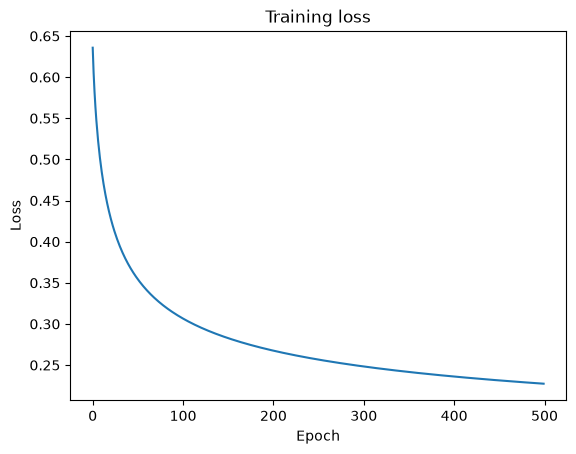

In [14]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss")
plt.show()

Comparison of Custom Model Against Sklearn Model

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Custom accuracy:", accuracy_score(y_validate, custom_pred))
print("Sklearn accuracy:", accuracy_score(y_validate, sklearn_pred))

print("Custom precision:", precision_score(y_validate, custom_pred))
print("Sklearn precision:", precision_score(y_validate, sklearn_pred))

print("Custom recall:", recall_score(y_validate, custom_pred))
print("Sklearn recall:", recall_score(y_validate, sklearn_pred))

print("Custom Macro F1:", f1_score(y_validate, custom_pred, average='macro'))
print("Sklearn Macro F1:", f1_score(y_validate, sklearn_pred, average='macro'))

print("Custom confusion matrix:")
print(confusion_matrix(y_validate, custom_pred))

print("Sklearn confusion matrix:")
print(confusion_matrix(y_validate, sklearn_pred))

Custom accuracy: 0.7192
Sklearn accuracy: 0.6792
Custom precision: 0.7685589519650655
Sklearn precision: 0.746757457846952
Custom recall: 0.7882277671145234
Sklearn recall: 0.736724248240563
Custom Macro F1: 0.6977496037161471
Sklearn Macro F1: 0.6592439634770713
Custom confusion matrix:
[[1132  742]
 [ 662 2464]]
Sklearn confusion matrix:
[[1093  781]
 [ 823 2303]]
